# Lab: Implement and evaluate a Neural Network for segmentation and object detection using COCO
Instructor: M.Sc. Mario Ivan Lopez Valdovinos

## Introduction
This project focuses on implementing and evaluating neural network models for object detection and instance segmentation using the COCO dataset. The models are trained to identify multiple object categories, locate them using bounding boxes, and generate pixel-level segmentation masks. Their performance is assessed using standard metrics such as precision, recall, Intersection over Union (IoU), and mean Average Precision (mAP).

## Step 1. Install Python, PyTorch, Ultralytics YOLO, and Matplotlib.
YOLO (You Only Look Once) is a single-stage detection model that unifies feature extraction and prediction within a deep neural network. For segmentation, it adds a head that predicts pixel-level masks using mask prototypes and coefficients. Ultralytics provides the most advanced and user-friendly implementation.

### 1.1: Imports

In [1]:
# System and path utilities
from pathlib import Path
from importlib.metadata import PackageNotFoundError, version

import os
import sys
import random
import shutil

# Data manipulation and visualization
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image

# Deep Learning libraries
import torch
import yaml

### 1.2: Environment detection

In [2]:
# Detect environment and configure workspace
IS_COLAB = "google.colab" in sys.modules

# Install dependencies in Colab
if IS_COLAB:
    %pip install -q ultralytics==8.4.102

print(f"Execution Environment: {'Google Colab' if IS_COLAB else 'Local Workspace / VS Code'}")

Execution Environment: Local Workspace / VS Code


### 1.3 System information and reproducibility

In [3]:
# Reproducibility configuration
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Hardware and versions
DEVICE = "CUDA" if torch.cuda.is_available() else "CPU"

try:
    INSTALLED_ULTRALYTICS = version("ultralytics")
except PackageNotFoundError:
    INSTALLED_ULTRALYTICS = "not installed"

# Print system specs)
print(f"Target Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
print(f"Random Seed: {SEED}")
print("-" * 60)
print(f"Python version: {sys.version.split()[0]}")
print(f"NumPy version: {np.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"Ultralytics version: {INSTALLED_ULTRALYTICS}")

Target Device: CUDA
GPU Name: NVIDIA GeForce RTX 3060
Random Seed: 42
------------------------------------------------------------
Python version: 3.11.15
NumPy version: 2.4.6
PyTorch version: 2.12.1
Ultralytics version: 8.4.115


## Step 2. Download the COCO dataset or use a smaller subset.
COCO (Common Objects in Context) is the gold standard for detection and segmentation, featuring 80 categories and over 200,000 annotated images. We use COCO128-seg, a subset of 128 images with segmentation annotations (polygons) that enable mask training, keeping the lab lightweight yet representative.

### 2.1: Workplace setup

In [4]:
# Workspace directory setup
if IS_COLAB:
    SESSION_WORKSPACE = Path("/content/yolo_coco_lab")
else:
    SESSION_WORKSPACE = Path.cwd() / "yolo_coco_lab"

SESSION_WORKSPACE.mkdir(parents=True, exist_ok=True)

### 2.2: COCO dataset download

In [5]:
# YOLO and COCO utilities
from ultralytics import YOLO, settings
from ultralytics.data.utils import check_det_dataset

# Configure datasets directory
SESSION_DATASETS = SESSION_WORKSPACE / "datasets"
# Update Ultralytics settings to store datasets in our workspace
settings.update({"datasets_dir": str(SESSION_DATASETS)})

print(f"Workspace Path: {SESSION_WORKSPACE}")
print(f"Datasets Path:  {SESSION_DATASETS}")

# Download COCO128 Instance Segmentation Dataset
# Note: coco128-seg contains polygon annotations required for masks
dataset_info = check_det_dataset("coco128-seg.yaml", autodownload=True)
coco_root = Path(dataset_info["path"])

# Raw dataset paths
raw_images_dir = coco_root / "images" / "train2017"
raw_labels_dir = coco_root / "labels" / "train2017"

# Gather image files and match with labels
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}
all_image_paths = sorted([
    p for p in raw_images_dir.glob("*") 
    if p.suffix.lower() in IMAGE_EXTENSIONS
])

Workspace Path: /home/timoteo/pCloudDrive/Cursos/AI Course/Módulo V - Deep Learning II/MSc Mario/Labs/Module_5/yolo_coco_lab
Datasets Path:  /home/timoteo/pCloudDrive/Cursos/AI Course/Módulo V - Deep Learning II/MSc Mario/Labs/Module_5/yolo_coco_lab/datasets

WARNING ⚠️ Dataset 'coco128-seg.yaml' images not found, missing path '/home/timoteo/pCloudDrive/Cursos/AI Course/Módulo V - Deep Learning II/MSc Mario/Labs/Module_5/yolo_coco_lab/datasets/coco128-seg/images/train2017'
Unzipping /home/timoteo/pCloudDrive/Cursos/AI Course/Módulo V - Deep Learning II/MSc Mario/Labs/Module_5/yolo_coco_lab/datasets/coco128-seg.zip to /home/timoteo/pCloudDrive/Cursos/AI Course/Módulo V - Deep Learning II/MSc Mario/Labs/Module_5/yolo_coco_lab/datasets/coco128-seg...: 100% ━━━━━━━━━━━━ 263/263 1.2Kfiles/s 0.2s<0.0s
Dataset download success ✅ (0.9s), saved to /home/timoteo/pCloudDrive/Cursos/AI Course/Módulo V - Deep Learning II/MSc Mario/Labs/Module_5/yolo_coco_lab/datasets



### Step 3. Divide the dataset into:
- 70% training
- 15% validation
- 15% testing
<br><br>
Stratified splitting ensures that each subset maintains the class distribution. The 70% allocated for training allows the model to learn general patterns, the 15% for validation is used to tune hyperparameters and prevent overfitting, and the 15% for testing evaluates performance on unseen data.

In [6]:
# Ensure reproducibility during dataset shuffling
random.seed(SEED)
random.shuffle(all_image_paths)

total_images = len(all_image_paths)

# Calculate split index boundaries (70% train, 15% val, 15% test)
train_end_idx = int(total_images * 0.70)
val_end_idx = train_end_idx + int(total_images * 0.15)

train_image_files = all_image_paths[:train_end_idx]
val_image_files = all_image_paths[train_end_idx:val_end_idx]
test_image_files = all_image_paths[val_end_idx:]

print("-" * 60)
print(f"Total Dataset Images: {total_images}")
print(f" - Train Split (70%):      {len(train_image_files)} images")
print(f" - Validation Split (15%): {len(val_image_files)} images")
print(f" - Test Split (15%):       {len(test_image_files)} images")


------------------------------------------------------------
Total Dataset Images: 128
 - Train Split (70%):      89 images
 - Validation Split (15%): 19 images
 - Test Split (15%):       20 images


### Step 4. Prepare the annotations for:
- Object detection using bounding boxes
- Instance segmentation using masks

<br>
YOLO uses .txt files with a specific format:

- Detection: `class_id x_center y_center width height` (normalized)
- Segmentation: `class_id x1 y1 x2 y2 ...` (normalized polygons)

Segmentation masks are stored as polygons because they are more space-efficient than bitmaps, and YOLO internally converts them into masks during training.

### 4.1. Function to organize dataset splits.

In [7]:
def organize_dataset_split(split_name, image_list):
    """
    Copies images and their corresponding label files to train/val/test folders.
    Labels contain bounding boxes (detection) and polygons (segmentation).
    """
    split_img_dir = coco_root / "images" / split_name
    split_lbl_dir = coco_root / "labels" / split_name
    
    split_img_dir.mkdir(parents=True, exist_ok=True)
    split_lbl_dir.mkdir(parents=True, exist_ok=True)
    
    for img_path in image_list:
        # Copy image
        shutil.copy2(img_path, split_img_dir / img_path.name)
        
        # Copy corresponding label file (.txt)
        label_file = raw_labels_dir / f"{img_path.stem}.txt"
        if label_file.exists():
            shutil.copy2(label_file, split_lbl_dir / label_file.name)
        else:
            # Empty file for background images (no annotations)
            (split_lbl_dir / f"{img_path.stem}.txt").touch()
    
    print(f"Split '{split_name}': {len(image_list)} images copied.")

### 4.2 Apply organization to all splits

In [8]:
organize_dataset_split("train", train_image_files)
organize_dataset_split("val", val_image_files)
organize_dataset_split("test", test_image_files)

Split 'train': 89 images copied.
Split 'val': 19 images copied.
Split 'test': 20 images copied.


### 4.3: Generate custom YAML configuration file

In [9]:
yaml_payload = {
    "path": coco_root.as_posix(),      # Root path
    "train": "images/train",            # Training images folder
    "val": "images/val",                # Validation images folder
    "test": "images/test",              # Test images folder
    "names": dataset_info["names"],     # 80 COCO class names
}

CUSTOM_YAML_PATH = SESSION_WORKSPACE / "coco_custom.yaml"
with open(CUSTOM_YAML_PATH, "w") as f:
    yaml.dump(yaml_payload, f, default_flow_style=False, sort_keys=False)

print(f"\nCustom YAML created at: {CUSTOM_YAML_PATH}")
print("Annotations prepared for both detection and segmentation!")


Custom YAML created at: /home/timoteo/pCloudDrive/Cursos/AI Course/Módulo V - Deep Learning II/MSc Mario/Labs/Module_5/yolo_coco_lab/coco_custom.yaml
Annotations prepared for both detection and segmentation!


### Step 5: Load a pretrained YOLO detection model.
YOLOv8n (nano) is the lightest version, featuring 3.2 million parameters and making it ideal for learning and deployment in resource-constrained environments. It utilizes pre-trained COCO weights for transfer learning, which significantly accelerates training by leveraging previously learned features (such as edges, textures, and shapes).

In [10]:
det_model = YOLO("yolov8n.pt")  # Pretrained on COCO

print(f"Model architecture: {det_model.model.model[-1].__class__.__name__}")
print(f"Number of classes: {len(det_model.names)}")

Model architecture: Detect
Number of classes: 80


### Step 6. Train the detection model using the training dataset.
The training optimizes the loss function that combines: 

- Box Loss (CIoU): Measures the precision of the box coordinates 
- Class Loss (BCE): Classifies the object 
- DFL Loss (Distribution Focal Loss): Refine the location

Using 10 epochs is sufficient for a small subset (128 images) and allows convergence to be observed without overtraining.

In [11]:
print("Initializing Detection Model Training...")
print(f"Dataset Configuration: {CUSTOM_YAML_PATH}")

# 6.1: Train the detection model
det_train_results = det_model.train(
    data=str(CUSTOM_YAML_PATH),
    epochs=10,                    # 10 epochs for quick training
    imgsz=640,                    # Standard YOLO input size
    batch=16,                     # Batch size (adjust based on GPU memory)
    seed=SEED,                    # Reproducibility
    project=str(SESSION_WORKSPACE / "runs"),
    name="yolo_detection_exp",
    verbose=False                 # Clean output
)

print("\n" + "=" * 60)
print("Detection model training completed successfully!")
print(f"Results saved to: {SESSION_WORKSPACE / 'runs' / 'yolo_detection_exp'}")
print("=" * 60)

Initializing Detection Model Training...
Dataset Configuration: /home/timoteo/pCloudDrive/Cursos/AI Course/Módulo V - Deep Learning II/MSc Mario/Labs/Module_5/yolo_coco_lab/coco_custom.yaml
New https://pypi.org/project/ultralytics/8.4.121 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.115 🚀 Python-3.11.15 torch-2.12.1 CUDA:0 (NVIDIA GeForce RTX 3060, 11900MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/timoteo/pCloudDrive/Cursos/AI Course/Módulo V - Deep Learning II/MSc Mario/Labs/Module_5/yolo_coco_lab/coco_custom.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed

### Step 7. Load a pretrained YOLO segmentation model.
The segmentation model `(yolov8n-seg.pt)` extends the detection architecture by adding a segmentation head that predicts:

- Prototypes: Base masks (32 in total)
- Coefficients: Weights to combine the prototypes per instance
- Final masks: Linear combination of weighted prototypes

It has 3.4M parameters (slightly more than the detection model) and 12.1 GFLOPs.

In [12]:
seg_model = YOLO("yolov8n-seg.pt")  # Pretrained on COCO with masks

print(f"Model architecture: {seg_model.model.model[-1].__class__.__name__}")
print(f"Number of classes: {len(seg_model.names)}")

Model architecture: Segment
Number of classes: 80


### Step 8. Train the segmentation model using the same dataset partitions.
The segmentation loss `(seg_loss)` uses BCE with logits for each pixel, comparing the predicted mask with the ground-truth mask (derived from the polygons). Joint training for detection and segmentation allows the network to learn shared features (backbone) and task-specific features (heads) simultaneously.

In [13]:
print("Initializing Segmentation Model Training...")
print(f"Dataset Configuration: {CUSTOM_YAML_PATH}")

# 8.1: Train the segmentation model (same epochs for fair comparison)
seg_train_results = seg_model.train(
    data=str(CUSTOM_YAML_PATH),
    epochs=10,                    # Same epochs as detection
    imgsz=640,
    batch=16,
    seed=SEED,
    project=str(SESSION_WORKSPACE / "runs"),
    name="yolo_segmentation_exp",
    verbose=False
)

print("\n" + "=" * 60)
print(f"Results saved to: {SESSION_WORKSPACE / 'runs' / 'yolo_segmentation_exp'}")
print("=" * 60)

Initializing Segmentation Model Training...
Dataset Configuration: /home/timoteo/pCloudDrive/Cursos/AI Course/Módulo V - Deep Learning II/MSc Mario/Labs/Module_5/yolo_coco_lab/coco_custom.yaml
New https://pypi.org/project/ultralytics/8.4.121 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.115 🚀 Python-3.11.15 torch-2.12.1 CUDA:0 (NVIDIA GeForce RTX 3060, 11900MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/timoteo/pCloudDrive/Cursos/AI Course/Módulo V - Deep Learning II/MSc Mario/Labs/Module_5/yolo_coco_lab/coco_custom.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, em

### Step 9. Evaluate both models using the test dataset.
Evaluation on the test set (20 unseen images) measures the model's true generalization capability. We use standard COCO metrics:

- **mAP@0.50:** Mean Average Precision with IoU = 0.5 (lenient)
- **mAP@0.50:0.95:** Mean Average Precision across 10 IoU thresholds (strict)

In [14]:
print("Evaluating Detection Model on Test Split...")
det_test_metrics = det_model.val(
    data=str(CUSTOM_YAML_PATH),
    split="test",
    verbose=False
)

print("\nEvaluating Segmentation Model on Test Split...")
seg_test_metrics = seg_model.val(
    data=str(CUSTOM_YAML_PATH),
    split="test",
    verbose=False
)

Evaluating Detection Model on Test Split...
Ultralytics 8.4.115 🚀 Python-3.11.15 torch-2.12.1 CUDA:0 (NVIDIA GeForce RTX 3060, 11900MiB)
Model summary (fused): 73 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access ✅ (ping: 0.1±0.0 ms, read: 288.4±73.2 MB/s, size: 50.2 KB)
val: Scanning /home/timoteo/pCloudDrive/Cursos/AI Course/Módulo V - Deep Learning II/MSc Mario/Labs/Module_5/yolo_coco_lab/datasets/coco128-seg/labels/test... 20 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 20/20 2.2Kit/s 0.0s
val: New cache created: /home/timoteo/pCloudDrive/Cursos/AI Course/Módulo V - Deep Learning II/MSc Mario/Labs/Module_5/yolo_coco_lab/datasets/coco128-seg/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 3.8it/s 0.5s1.3s
                   all         20        106      0.602      0.718      0.799      0.624
Speed: 2.2ms preprocess, 20.7ms inference, 0.0ms loss, 0.9ms postprocess per 

### Step 10. Record the following detection metrics:
- **Precision:** $\frac{TP}{TP +FP}$ - How many of the detected objects are correct?
- **Recall:** $\frac{TP}{TP+FN}$ - How many of the actual objects were detected?
- **F1-score:** Harmonic mean of precision and recall
- **mAP@0.50:** Mean of average precisions with IoU = 0.5
- **mAP@0.50:0.95:** Mean of mAP across 10 IoU thresholds (0.5 to 0.95) 


In [15]:
# 10.1: Extract detection metrics
det_p = det_test_metrics.box.mp      # Precision
det_r = det_test_metrics.box.mr      # Recall
det_f1 = 2 * (det_p * det_r) / (det_p + det_r + 1e-16)  # F1-score
det_map50 = det_test_metrics.box.map50      # mAP@0.50
det_map50_95 = det_test_metrics.box.map      # mAP@0.50:0.95

# 10.2: Display metrics
print("\n" + "=" * 60)
print("RECORDED DETECTION METRICS (TEST SET)")
print("=" * 60)
print(f" Precision:              {det_p:.4f}")
print(f" Recall:                 {det_r:.4f}")
print(f" F1-Score:               {det_f1:.4f}")
print(f" mAP@0.50:               {det_map50:.4f}")
print(f" mAP@0.50:0.95:          {det_map50_95:.4f}")
print("=" * 60)


RECORDED DETECTION METRICS (TEST SET)
 Precision:              0.6019
 Recall:                 0.7184
 F1-Score:               0.6550
 mAP@0.50:               0.7992
 mAP@0.50:0.95:          0.6242


### Step 11. Record the following segmentation metrics:
- Mask precision
- Mask recall
- Mask mAP@0.50
- Mask mAP@0.50:0.95
- Intersection over Union
- Dice coefficient

For masks, in addition to precision, recall, and mAP, we calculate pixel-level metrics:

- **IoU (Intersection over Union):** $\frac{|A \cap B|}{| A \cup B|}$ Measures exact overlap
- **Dice Coefficient:** $\frac{2|A \cap B|}{|A| + |B|}$ Similar to IoU but more sensitive to false negatives

Both are critical for medical or autonomous applications where spatial precision matters.

When YOLO processes an image, it applies:

1. **Resize:** Resizes the image to `imgsz` (640 in our case) while maintaining the aspect ratio.
2. **Letterbox:** Adds padding to preserve the aspect ratio.
3. **Normalization:** Scales pixel values ​​to the [0, 1] range.

Consequently, the predicted masks exist in the processed image space, not the original one. We must either **resize the ground-truth mask to match the prediction size or resize the prediction to the original image size**.

**Best practice:** Resize the predicted mask to the original image size (this is more accurate for evaluation).

In [16]:
# 11.1: Helper function for polygon to mask conversion
def polygons_to_mask(polygons, img_shape):
    """Convert normalized polygon coordinates to binary mask."""
    mask = np.zeros(img_shape[:2], dtype=np.uint8)
    for poly in polygons:
        if len(poly) >= 6:  # At least 3 points (6 coordinates)
            pts = np.array(poly, dtype=np.int32).reshape((-1, 1, 2))
            cv2.fillPoly(mask, [pts], 1)
    return mask.astype(bool)

# 11.2: Helper function for IoU and Dice (con verificación de dimensiones)
def compute_mask_metrics(gt_mask, pred_mask):
    """
    Calculate IoU and Dice between two binary masks.
    Handles different dimensions by resizing pred_mask to gt_mask size.
    """
    # Check if dimensions match
    if gt_mask.shape != pred_mask.shape:
        # Resize pred_mask to match gt_mask dimensions using nearest neighbor
        # (important for binary masks)
        pred_mask = cv2.resize(
            pred_mask.astype(np.uint8), 
            (gt_mask.shape[1], gt_mask.shape[0]),  # (width, height)
            interpolation=cv2.INTER_NEAREST
        ).astype(bool)
    
    gt_bool = gt_mask.astype(bool)
    pred_bool = pred_mask.astype(bool)
    
    intersection = np.logical_and(gt_bool, pred_bool).sum()
    union = np.logical_or(gt_bool, pred_bool).sum()
    total = gt_bool.sum() + pred_bool.sum()
    
    iou = intersection / union if union > 0 else 1.0
    dice = (2.0 * intersection) / total if total > 0 else 1.0
    
    return float(iou), float(dice)

# 11.3: Extract segmentation metrics from validation
mask_p = seg_test_metrics.seg.mp          # Mask Precision
mask_r = seg_test_metrics.seg.mr          # Mask Recall
mask_map50 = seg_test_metrics.seg.map50   # Mask mAP@0.50
mask_map50_95 = seg_test_metrics.seg.map  # Mask mAP@0.50:0.95

# 11.4: Calculate IoU and Dice on test images (con manejo de dimensiones)
test_img_dir = coco_root / "images" / "test"
test_lbl_dir = coco_root / "labels" / "test"
test_image_paths = list(test_img_dir.glob("*.jpg"))

iou_list, dice_list = [], []

print("Calculating IoU and Dice on test images...")

for idx, img_path in enumerate(test_image_paths):
    # Load image to get original dimensions
    img = cv2.imread(str(img_path))
    original_h, original_w = img.shape[:2]
    
    # Load ground truth mask from label file (in original image space)
    label_path = test_lbl_dir / f"{img_path.stem}.txt"
    gt_polygons = []
    
    if label_path.exists():
        with open(label_path, "r") as f:
            for line in f.readlines():
                parts = list(map(float, line.strip().split()))
                if len(parts) > 5:  # Segmentation annotation (has polygon)
                    coords = parts[1:]
                    # Convert normalized coordinates to absolute pixel values
                    poly = [(coords[i] * original_w, coords[i+1] * original_h) 
                            for i in range(0, len(coords), 2)]
                    gt_polygons.append(poly)
    
    # Create ground truth mask in original image space
    gt_mask = polygons_to_mask(gt_polygons, (original_h, original_w))
    
    # Get predicted mask from segmentation model
    # IMPORTANT: We need to use the original image for prediction
    results = seg_model.predict(source=str(img_path), imgsz=640, verbose=False)[0]
    
    if results.masks is not None:
        # Predicted masks are in the model's processed space (640x640)
        # We need to resize them to original image dimensions
        pred_masks = results.masks.data.cpu().numpy()  # Shape: (N, processed_h, processed_w)
        
        # Get the processed image dimensions from the results
        processed_h, processed_w = pred_masks.shape[1], pred_masks.shape[2]
        
        # Resize each predicted mask to original image size
        resized_masks = []
        for mask in pred_masks:
            # Convert to uint8 for OpenCV
            mask_uint8 = mask.astype(np.uint8) * 255
            # Resize to original dimensions
            resized_mask = cv2.resize(
                mask_uint8, 
                (original_w, original_h),  # (width, height)
                interpolation=cv2.INTER_NEAREST
            )
            # Convert back to boolean
            resized_mask_bool = (resized_mask > 127).astype(bool)
            resized_masks.append(resized_mask_bool)
        
        # Combine all instance masks into a single binary mask
        if resized_masks:
            combined_pred_mask = np.any(resized_masks, axis=0)
        else:
            combined_pred_mask = np.zeros((original_h, original_w), dtype=bool)
    else:
        combined_pred_mask = np.zeros((original_h, original_w), dtype=bool)
    
    # Compute metrics (now both masks have the same dimensions)
    iou, dice = compute_mask_metrics(gt_mask, combined_pred_mask)
    iou_list.append(iou)
    dice_list.append(dice)
    
    # Print progress every 5 images
    if (idx + 1) % 5 == 0:
        print(f"  Processed {idx + 1}/{len(test_image_paths)} images")

# 11.5: Calculate mean metrics
mean_iou = np.mean(iou_list) if iou_list else 0.0
mean_dice = np.mean(dice_list) if dice_list else 0.0

# 11.6: Display segmentation metrics
print("\n" + "=" * 60)
print("RECORDED SEGMENTATION METRICS (TEST SET)")
print("=" * 60)
print(f" Mask Precision:          {mask_p:.4f}")
print(f" Mask Recall:             {mask_r:.4f}")
print(f" Mask mAP@0.50:           {mask_map50:.4f}")
print(f" Mask mAP@0.50:0.95:      {mask_map50_95:.4f}")
print(f" Mean IoU (pixel-level):  {mean_iou:.4f}")
print(f" Mean Dice Coefficient:   {mean_dice:.4f}")
print("=" * 60)

# 11.7: Additional statistics
print("\nIoU/Dice Statistics:")
print(f"  IoU  - Min: {min(iou_list):.4f}, Max: {max(iou_list):.4f}, Std: {np.std(iou_list):.4f}")
print(f"  Dice - Min: {min(dice_list):.4f}, Max: {max(dice_list):.4f}, Std: {np.std(dice_list):.4f}")
print("=" * 60)

Calculating IoU and Dice on test images...
  Processed 5/20 images
  Processed 10/20 images
  Processed 15/20 images
  Processed 20/20 images

RECORDED SEGMENTATION METRICS (TEST SET)
 Mask Precision:          0.8832
 Mask Recall:             0.5285
 Mask mAP@0.50:           0.7199
 Mask mAP@0.50:0.95:      0.5176
 Mean IoU (pixel-level):  0.7109
 Mean Dice Coefficient:   0.7882

IoU/Dice Statistics:
  IoU  - Min: 0.0000, Max: 0.9593, Std: 0.2701
  Dice - Min: 0.0000, Max: 0.9792, Std: 0.2756


### Step 12. Display several test images with:
- Ground-truth annotations
- Predicted bounding boxes
- Predicted masks
- Confidence scores

Qualitative evaluation is essential to understand model behavior beyond numbers. By visualizing:

- **Ground Truth (green):** Shows what the model should detect
- **Detection Predictions (blue boxes + confidence scores):** Shows what the model found
- **Segmentation Predictions (colored masks + confidence):** Shows pixel-level accuracy

This helps identify failure cases (small objects, occlusions, false positives) and validates that metrics like mAP correlate with visual quality.

VISUALIZING TEST IMAGES
------------------------------------------------------------
Total test images: 20
Selected 3 images for visualization

Processing image 1: 000000000034.jpg
   GT objects: 1
   Detections: 1 (avg conf: 0.904)
   Masks: 1

Processing image 2: 000000000036.jpg
   GT objects: 2
   Detections: 2 (avg conf: 0.816)
   Masks: 2

Processing image 3: 000000000073.jpg
   GT objects: 2
   Detections: 1 (avg conf: 0.803)
   Masks: 4

Visualization saved to: /home/timoteo/pCloudDrive/Cursos/AI Course/Módulo V - Deep Learning II/MSc Mario/Labs/Module_5/yolo_coco_lab/test_visualizations.png


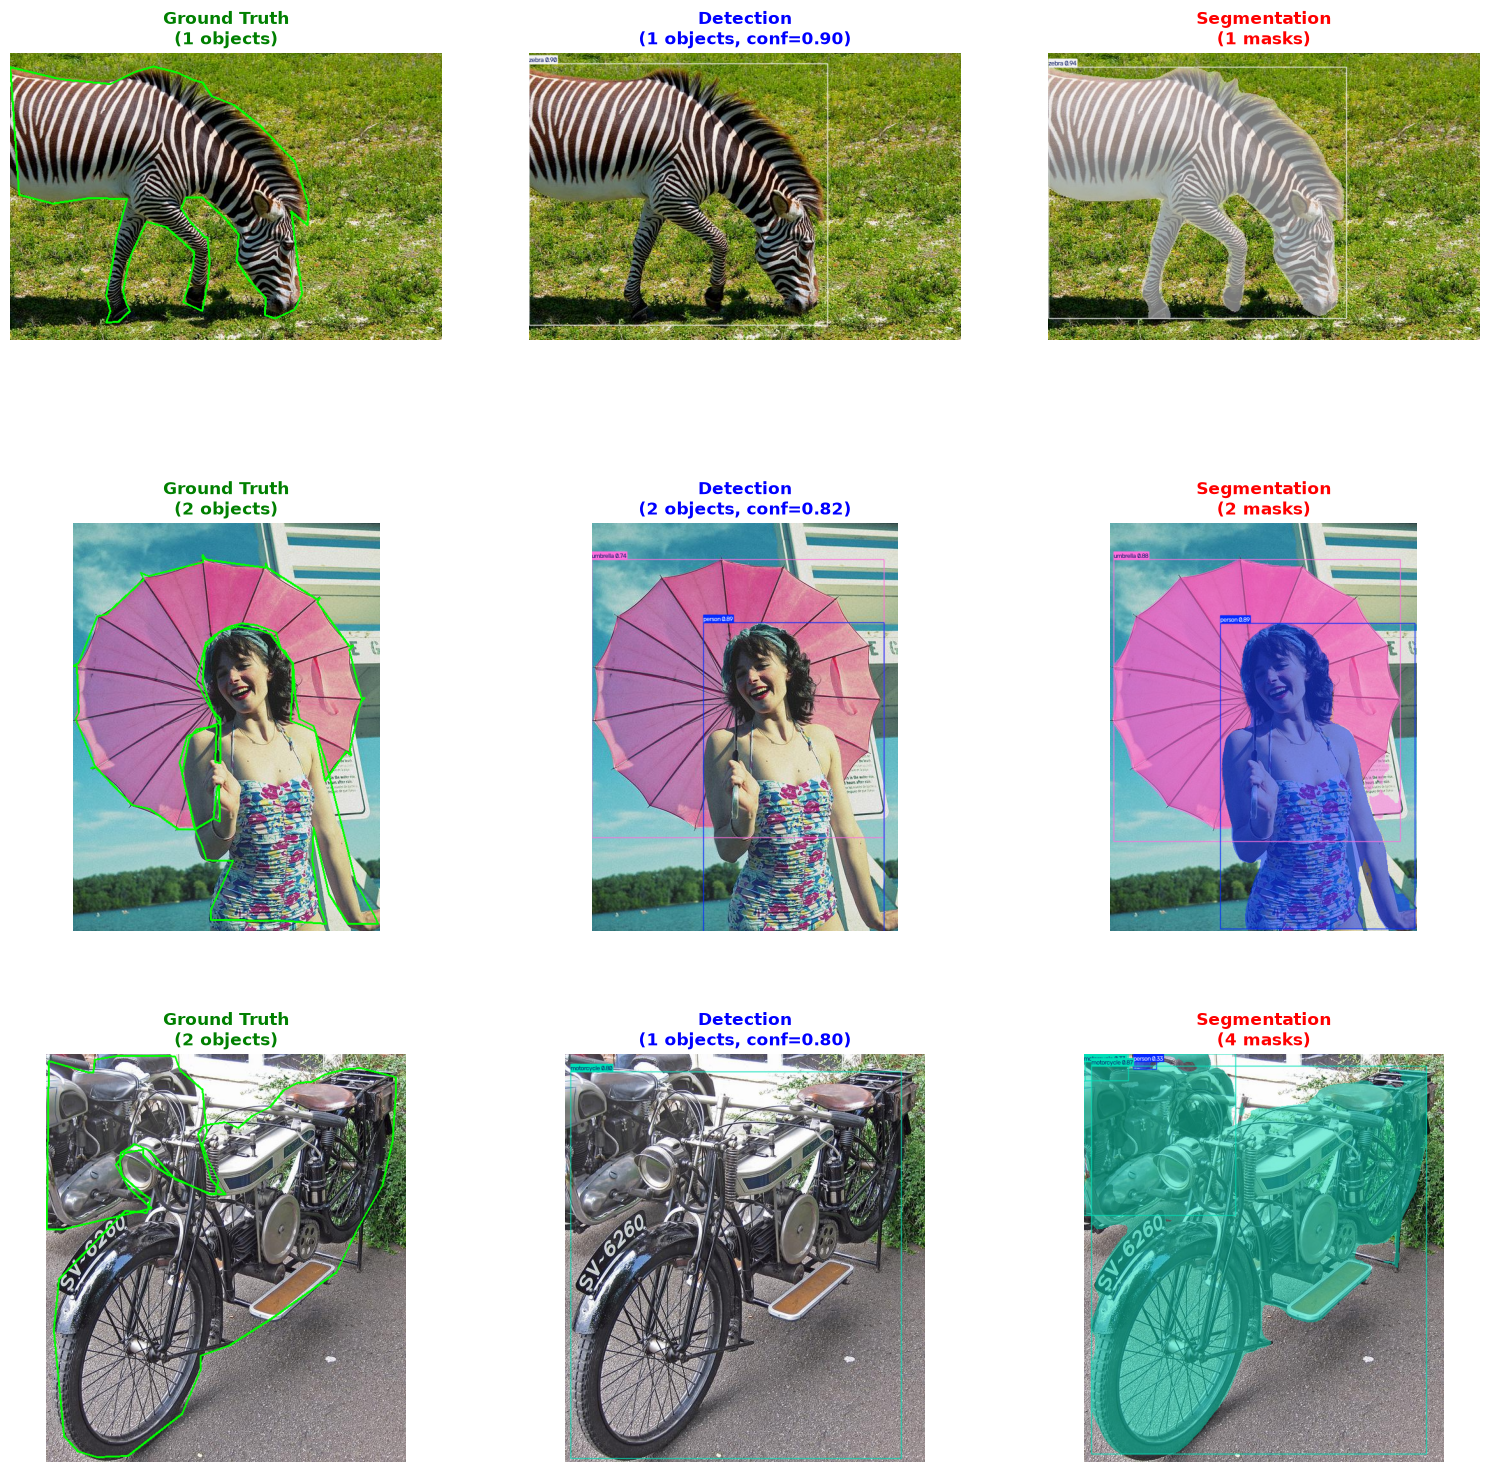

------------------------------------------------------------
Displayed 3 test images
Saved visualization to: /home/timoteo/pCloudDrive/Cursos/AI Course/Módulo V - Deep Learning II/MSc Mario/Labs/Module_5/yolo_coco_lab/test_visualizations.png
------------------------------------------------------------


In [17]:
# 12.1: Configure matplotlib for Jupyter
%matplotlib inline

print("VISUALIZING TEST IMAGES")
print("-" * 60)

# 12.2: Get test images with annotations
test_img_dir = coco_root / "images" / "test"
test_lbl_dir = coco_root / "labels" / "test"

# Get all test images
all_test_images = list(test_img_dir.glob("*.jpg"))
print(f"Total test images: {len(all_test_images)}")

# Select first 3 images with valid annotations
selected_images = []
for img_path in all_test_images[:10]:  # Check first 10
    label_path = test_lbl_dir / f"{img_path.stem}.txt"
    if label_path.exists() and label_path.stat().st_size > 0:
        selected_images.append(img_path)
        if len(selected_images) >= 3:
            break

# If not enough, use whatever we have
if len(selected_images) < 2:
    selected_images = all_test_images[:3]

print(f"Selected {len(selected_images)} images for visualization")

# 12.3: Function to draw ground truth
def draw_ground_truth(image, label_path):
    """
    Draw green bounding boxes and polygons from ground truth labels.
    """
    h, w = image.shape[:2]
    img_gt = image.copy()
    num_objects = 0
    
    if not label_path.exists():
        return img_gt, 0
    
    with open(label_path, "r") as f:
        for line in f:
            parts = list(map(float, line.strip().split()))
            
            if len(parts) == 5:  # Bounding box
                cls, xc, yc, bw, bh = parts
                x1 = int((xc - bw/2) * w)
                y1 = int((yc - bh/2) * h)
                x2 = int((xc + bw/2) * w)
                y2 = int((yc + bh/2) * h)
                
                # Draw green rectangle
                cv2.rectangle(img_gt, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(img_gt, "GT", (x1, y1-5), 
                           cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
                num_objects += 1
                
            elif len(parts) > 5:  # Polygon (segmentation)
                coords = parts[1:]
                poly = [(int(coords[i] * w), int(coords[i+1] * h)) 
                        for i in range(0, len(coords), 2)]
                pts = np.array(poly, dtype=np.int32).reshape((-1, 1, 2))
                cv2.polylines(img_gt, [pts], True, (0, 255, 0), 2)
                num_objects += 1
    
    return img_gt, num_objects

# 12.4: Create visualization
fig, axes = plt.subplots(len(selected_images), 3, figsize=(15, 5*len(selected_images)))

# Handle single image case
if len(selected_images) == 1:
    axes = axes.reshape(1, -1)

# 12.5: Process each image
for idx, img_path in enumerate(selected_images):
    print(f"\nProcessing image {idx+1}: {img_path.name}")
    
    # Load image
    img_bgr = cv2.imread(str(img_path))
    
    # --- Column 1: Ground Truth ---
    label_path = test_lbl_dir / f"{img_path.stem}.txt"
    img_gt, num_gt = draw_ground_truth(img_bgr, label_path)
    axes[idx, 0].imshow(cv2.cvtColor(img_gt, cv2.COLOR_BGR2RGB))
    axes[idx, 0].set_title(f"Ground Truth\n({num_gt} objects)", fontweight='bold', color='green')
    axes[idx, 0].axis('off')
    
    # --- Column 2: Detection Prediction ---
    det_results = det_model.predict(source=str(img_path), conf=0.25, verbose=False)[0]
    det_img = det_results.plot(masks=False, line_width=1)
    axes[idx, 1].imshow(cv2.cvtColor(det_img, cv2.COLOR_BGR2RGB))
    
    # Get detection info
    num_det = len(det_results.boxes) if det_results.boxes is not None else 0
    avg_conf = det_results.boxes.conf.mean().item() if num_det > 0 else 0
    axes[idx, 1].set_title(f"Detection\n({num_det} objects, conf={avg_conf:.2f})", 
                          fontweight='bold', color='blue')
    axes[idx, 1].axis('off')
    
    # --- Column 3: Segmentation Prediction ---
    seg_results = seg_model.predict(source=str(img_path), conf=0.25, verbose=False)[0]
    seg_img = seg_results.plot(masks=True, line_width=1)
    axes[idx, 2].imshow(cv2.cvtColor(seg_img, cv2.COLOR_BGR2RGB))
    
    # Get segmentation info
    num_masks = len(seg_results.masks) if seg_results.masks is not None else 0
    axes[idx, 2].set_title(f"Segmentation\n({num_masks} masks)", 
                          fontweight='bold', color='red')
    axes[idx, 2].axis('off')
    
    # Print summary
    print(f"   GT objects: {num_gt}")
    print(f"   Detections: {num_det} (avg conf: {avg_conf:.3f})")
    print(f"   Masks: {num_masks}")

# 12.6: Adjust layout and display
plt.tight_layout()
plt.subplots_adjust(wspace=0.2, hspace=0.3)

# 12.7: Save figure
output_path = SESSION_WORKSPACE / "test_visualizations.png"
plt.savefig(output_path, dpi=120, bbox_inches='tight', facecolor='white')
print(f"\nVisualization saved to: {output_path}")

# 12.8: Display
plt.show()

# 12.9: Final summary
print("-" * 60)
print(f"Displayed {len(selected_images)} test images")
print(f"Saved visualization to: {output_path}")
print("-" * 60)